# 05 - Retrieval Evaluation

- Build the retrieval benchmark automatically if it is missing.
- Compare BM25, FAISS, and Hybrid retrieval quality and latency.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.rag.evaluation import (
    EvaluationDataset,
    RetrievalEvaluator,
    compare_retrievers,
    bootstrap_confidence_intervals,
)
from src.rag.runtime import load_retrieval_stack

In [2]:
EVAL_PATH = (
    PROJECT_ROOT
    / "data"
    / "evaluation"
    / "retrieval_queries.json"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "evaluation"
    / "results"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

KS = (1, 3, 5, 10)

if not EVAL_PATH.exists():
    import subprocess

    print(
        "Retrieval benchmark is missing. "
        "Generating it now with the configured LLM."
    )

    subprocess.run(
        [
            sys.executable,
            str(
                PROJECT_ROOT
                / "scripts"
                / "generate_eval_dataset.py"
            ),
        ],
        cwd=PROJECT_ROOT,
        check=True,
    )

if not EVAL_PATH.exists():
    raise FileNotFoundError(
        f"Retrieval benchmark was not created: {EVAL_PATH}"
    )

dataset = EvaluationDataset(EVAL_PATH)
stack = load_retrieval_stack(PROJECT_ROOT)

retrievers = {
    "bm25": stack.bm25,
    "embedding": stack.embedding,
    "hybrid": stack.hybrid,
}

print("Samples:", len(dataset))
print(
    "Products:",
    len({sample["product_id"] for sample in dataset}),
)

Retrieval benchmark is missing. Generating it now with the configured LLM.
Products: 1/50 | Samples: 3 | API calls this run: 1 | Cost this run: $0.0025
Products: 2/50 | Samples: 6 | API calls this run: 2 | Cost this run: $0.0038
Products: 3/50 | Samples: 9 | API calls this run: 3 | Cost this run: $0.0051
Products: 4/50 | Samples: 12 | API calls this run: 4 | Cost this run: $0.0069
Products: 5/50 | Samples: 15 | API calls this run: 5 | Cost this run: $0.0090
Products: 6/50 | Samples: 18 | API calls this run: 6 | Cost this run: $0.0107
Products: 7/50 | Samples: 21 | API calls this run: 7 | Cost this run: $0.0127
Products: 8/50 | Samples: 24 | API calls this run: 8 | Cost this run: $0.0151
Products: 9/50 | Samples: 27 | API calls this run: 9 | Cost this run: $0.0167
Products: 10/50 | Samples: 30 | API calls this run: 10 | Cost this run: $0.0188
Products: 11/50 | Samples: 33 | API calls this run: 11 | Cost this run: $0.0202
Products: 12/50 | Samples: 36 | API calls this run: 12 | Cost this

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Samples: 150
Products: 50


## Smoke check

- Verify retrieval on one benchmark query.

In [3]:
sample = dataset.samples[0]

print("Query:", sample["query"])
print("Relevant IDs:", sample["relevant_ids"])

for name, retriever in retrievers.items():
    print("\n", name.upper())

    results = retriever.retrieve(
        sample["query"],
        top_k=5,
        candidate_ids=sample["candidate_ids"],
    )

    display(results[["id", "score", "body"]])

Query: برای پوست چرب باعث جوش می‌شود؟
Relevant IDs: [37147768, 53850976]

 BM25


,id,score,body
0,37147768,19.530163,برای پوست چرب خوبه جوش نمی زنه و بی رنگ هست رو...
1,53850976,6.997633,سبکه بوی خوبی داره پوستم چربه خوشبختانه باهاش ...
2,19986013,6.122055,عالیه، روی پوست خیلی خوب وایمیسه
3,11291884,5.969067,من برای استفاده روزانه گرفتم قیمت و پوشانندگی ...
4,54217832,5.740392,سبک.مناسب پوست روشن.پوست تیره نوع بژ طبیعیش هس...



 EMBEDDING


,id,score,body
0,37147768,0.754324,برای پوست چرب خوبه جوش نمی زنه و بی رنگ هست رو...
1,53850976,0.642862,سبکه بوی خوبی داره پوستم چربه خوشبختانه باهاش ...
2,19986013,0.619591,عالیه، روی پوست خیلی خوب وایمیسه
3,54217832,0.618978,سبک.مناسب پوست روشن.پوست تیره نوع بژ طبیعیش هس...
4,11291884,0.593108,من برای استفاده روزانه گرفتم قیمت و پوشانندگی ...



 HYBRID


,id,score,body
0,37147768,1.000000,برای پوست چرب خوبه جوش نمی زنه و بی رنگ هست رو...
1,53850976,0.620434,سبکه بوی خوبی داره پوستم چربه خوشبختانه باهاش ...
2,19986013,0.573497,عالیه، روی پوست خیلی خوب وایمیسه
3,54217832,0.565606,سبک.مناسب پوست روشن.پوست تیره نوع بژ طبیعیش هس...
4,11291884,0.535736,من برای استفاده روزانه گرفتم قیمت و پوشانندگی ...


## Full benchmark

- Evaluate all retrieval methods.

In [4]:
summary, per_query = compare_retrievers(
    retrievers=retrievers,
    dataset=dataset,
    ks=KS,
)

headline_columns = [
    "precision@5",
    "recall@5",
    "hit_rate@5",
    "mrr@5",
    "map@5",
    "ndcg@5",
    "latency_mean_ms",
    "latency_p50_ms",
    "latency_p95_ms",
]

display(summary.round(4))
display(summary[headline_columns].round(4))

,precision@1,recall@1,hit_rate@1,mrr@1,map@1,ndcg@1,precision@3,recall@3,hit_rate@3,mrr@3,...,ndcg@5,precision@10,recall@10,hit_rate@10,mrr@10,map@10,ndcg@10,latency_mean_ms,latency_p50_ms,latency_p95_ms
retriever,,,,,,,,,,,,,,,,,,,,,
bm25,0.6467,0.5522,0.6467,0.6467,0.6467,0.6467,0.3200,0.7644,0.8267,0.7289,...,0.7499,0.1207,0.9478,0.9733,0.7548,0.7188,0.7847,90.8731,87.0860,109.2736
embedding,0.6067,0.5089,0.6067,0.6067,0.6067,0.6067,0.3067,0.7456,0.8200,0.7033,...,0.7280,0.1213,0.9378,0.9533,0.7299,0.6849,0.7601,99.5727,91.6331,123.8986
hybrid,0.6933,0.5922,0.6933,0.6933,0.6933,0.6933,0.3333,0.7944,0.8667,0.7700,...,0.7883,0.1240,0.9611,0.9800,0.7918,0.7521,0.8149,263.8183,261.4622,278.5299


,precision@5,recall@5,hit_rate@5,mrr@5,map@5,ndcg@5,latency_mean_ms,latency_p50_ms,latency_p95_ms
retriever,,,,,,,,,
bm25,0.2147,0.8500,0.8867,0.7422,0.7024,0.7499,90.8731,87.0860,109.2736
embedding,0.2160,0.8522,0.9000,0.7220,0.6665,0.7280,99.5727,91.6331,123.8986
hybrid,0.2253,0.8900,0.9333,0.7850,0.7370,0.7883,263.8183,261.4622,278.5299


## Quality comparison

- Plot key ranking metrics.

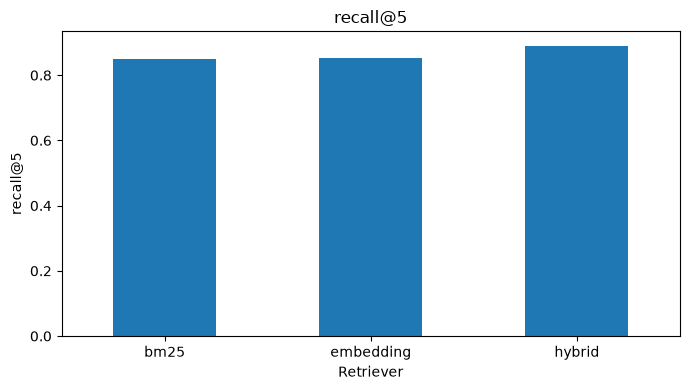

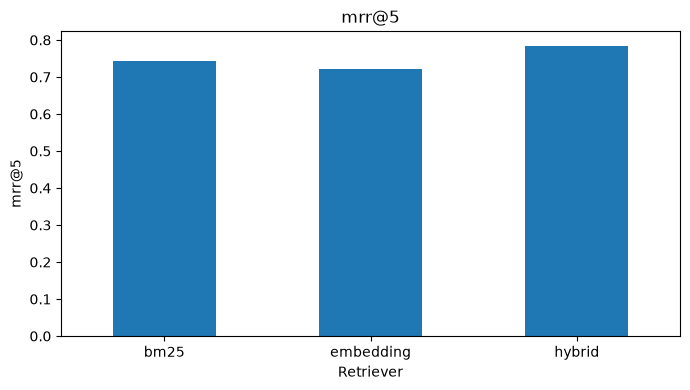

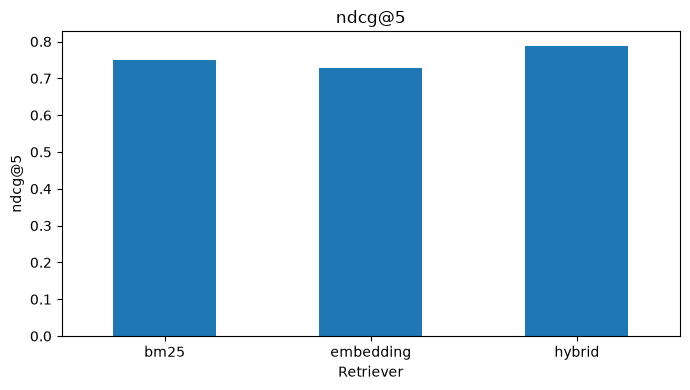

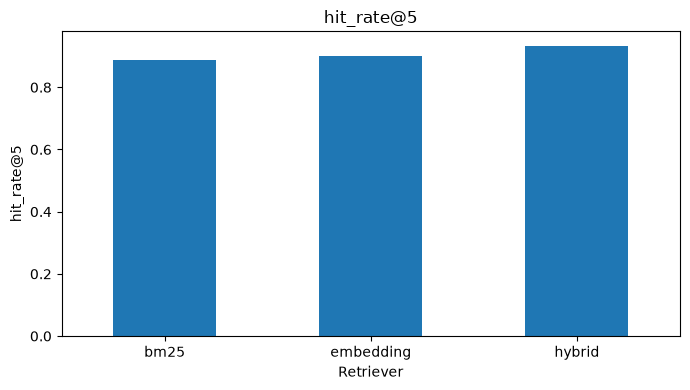

In [5]:
for metric in [
    "recall@5",
    "mrr@5",
    "ndcg@5",
    "hit_rate@5",
]:
    ax = summary[metric].plot(
        kind="bar",
        figsize=(7, 4),
        title=metric,
    )
    ax.set_xlabel("Retriever")
    ax.set_ylabel(metric)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Confidence intervals

- Estimate bootstrap intervals for key metrics.

In [6]:
confidence_intervals = bootstrap_confidence_intervals(
    per_query,
    metrics=("recall@5", "mrr@5", "ndcg@5"),
)

display(confidence_intervals.round(4))

,retriever,metric,mean,ci_low,ci_high
0,bm25,recall@5,0.8500,0.7900,0.9022
1,bm25,mrr@5,0.7422,0.6836,0.8028
2,bm25,ndcg@5,0.7499,0.6961,0.8032
3,embedding,recall@5,0.8522,0.7967,0.9022
4,embedding,mrr@5,0.7220,0.6609,0.7803
5,embedding,ndcg@5,0.7280,0.6722,0.7805
6,hybrid,recall@5,0.8900,0.8433,0.9322
7,hybrid,mrr@5,0.7850,0.7289,0.8373
8,hybrid,ndcg@5,0.7883,0.7396,0.8346


## Failure analysis

- Inspect low-recall queries.

In [7]:
for name in retrievers:
    method_results = per_query[
        per_query["retriever"] == name
    ]

    print("\n", name.upper())

    display(
        RetrievalEvaluator.failure_cases(
            method_results,
            metric="recall@5",
            n=10,
        )[
            [
                "product_id",
                "query",
                "relevant_ids",
                "retrieved_ids",
                "recall@5",
                "latency_ms",
            ]
        ]
    )


 BM25


,product_id,query,relevant_ids,retrieved_ids,recall@5,latency_ms
20,3019282,برای هدیه دادن، ظاهر و بسته‌بندی این عطر مناسب...,"[35798941, 30244769]","[31474479, 38199946, 46388919, 33023352, 37615...",0.0,104.089724
10,3177062,آیا این خودکار طرح استخوانی برای نوشتن روزمره ...,[49277974],"[53575981, 23081625, 42319532, 32638372, 49299...",0.0,104.072052
9,3177062,آیا جوهر این خودکارها کم است و می‌شود آن را تع...,[50978818],"[49299822, 49206357, 49277974, 23081625, 53575...",0.0,100.059278
78,1612079,آیا برای هدیه، عطر پلمپ و با حجم کامل ارسال می...,[19635084],"[5185572, 52156621, 5729925, 38953440, 5360368...",0.0,95.445563
90,1531259,برای دوچرخه‌سواری و کوهنوردی در تابستان مناسبه؟,[42743103],"[45706698, 44920454, 47155795, 48078178, 14924...",0.0,94.194948
138,2774253,آیا گزارشگر فارسی عادل فردوسی‌پور در بازی وجود...,"[31897137, 10043318, 10873437]","[18668637, 53362688, 46304876, 38988942, 20906...",0.0,88.158075
26,7812726,قیمت این جامدادی نسبت به کیفیتش چطور است؟,[33486667],"[48590890, 34214273, 33919422, 53182104]",0.0,87.867623
61,7625927,ترجمه کتاب راز از انتشارات نگین ایران روان و خ...,"[37893768, 39692428]","[35170629, 36091937, 32898923, 34323606, 41834...",0.0,87.714076
73,8056875,برای ضبط پادکست و صحبت کردن، کیفیت و نویز این ...,[40418054],"[37830935, 47736761, 44323338, 41241507, 35345...",0.0,87.010906
65,769908,آیا رنگ نهایی این محصول مطابق رنگ دلخواه خریدا...,[49604750],"[41907851, 46971565, 47383380, 38601215, 49238...",0.0,87.004511



 EMBEDDING


,product_id,query,relevant_ids,retrieved_ids,recall@5,latency_ms
159,3177062,آیا جوهر این خودکارها کم است و می‌شود آن را تع...,[50978818],"[39329971, 49299822, 49206357, 49277974, 23081...",0.0,121.090670
222,8056875,آیا کارت صدای این پک بلوتوث دارد و شارژی است؟,[42619948],"[47736761, 37830935, 42498323, 38653663, 35345...",0.0,118.613714
228,1612079,آیا برای هدیه، عطر پلمپ و با حجم کامل ارسال می...,[19635084],"[52156621, 5062360, 52620723, 5185572, 4769791...",0.0,109.567032
225,1117497,این قرص‌نصف‌کن برای کپسول یا قرص‌های روکش‌دار ...,[2734013],"[26112856, 16519735, 8196451, 45494909, 158547...",0.0,106.402202
170,3019282,برای هدیه دادن، ظاهر و بسته‌بندی این عطر مناسب...,"[35798941, 30244769]","[46388919, 33023352, 37615386, 31474479, 38199...",0.0,102.191870
173,3028331,فونت این چاپ کتاب کوری خوب است؟,[50985320],"[34305084, 22181810, 34958439, 39722865, 11904...",0.0,95.095459
267,6643052,درب این قندان کاملاً کیپ بسته می‌شود؟,[29503833],"[49111198, 49487263, 42949496, 35845923, 33238...",0.0,94.606537
167,3853842,آیا ممکن است به جای کرم ژل، مدل واتر ژل ارسال ...,[19308749],"[36394011, 15378820, 39025234, 21959041, 30520...",0.0,94.366498
181,237186,آیا کتاب با تخفیف و قیمت مناسب به دست خریدار ر...,[28462379],"[23627688, 16506416, 34534879, 43420537, 21053...",0.0,91.810466
223,8056875,برای ضبط پادکست و صحبت کردن، کیفیت و نویز این ...,[40418054],"[37830935, 44323338, 36503492, 41241507, 35345...",0.0,89.746621



 HYBRID


,product_id,query,relevant_ids,retrieved_ids,recall@5,latency_ms
407,4744467,بوی این صابون چطور است؟,[46573001],"[50473295, 50171689, 42564401, 49315749, 43715...",0.0,269.199980
373,8056875,برای ضبط پادکست و صحبت کردن، کیفیت و نویز این ...,[40418054],"[37830935, 44323338, 41241507, 35345039, 47736...",0.0,267.545331
309,3177062,آیا جوهر این خودکارها کم است و می‌شود آن را تع...,[50978818],"[49299822, 49206357, 39329971, 49277974, 23081...",0.0,267.470250
320,3019282,برای هدیه دادن، ظاهر و بسته‌بندی این عطر مناسب...,"[35798941, 30244769]","[46388919, 31474479, 33023352, 38199946, 37615...",0.0,262.072402
378,1612079,آیا برای هدیه، عطر پلمپ و با حجم کامل ارسال می...,[19635084],"[52156621, 5185572, 5062360, 38953440, 5360368...",0.0,260.379479
365,769908,آیا رنگ نهایی این محصول مطابق رنگ دلخواه خریدا...,[49604750],"[46971565, 49238778, 41907851, 49788437, 38601...",0.0,259.934289
323,3028331,فونت این چاپ کتاب کوری خوب است؟,[50985320],"[34958439, 34305084, 11904521, 22181810, 39722...",0.0,259.399330
372,8056875,آیا کارت صدای این پک بلوتوث دارد و شارژی است؟,[42619948],"[37830935, 47736761, 42498323, 38653663, 35345...",0.0,258.450819
371,7082738,جنس جلد و برگه‌های این دفتر چه کیفیتی دارد؟,[35019110],"[38797849, 53731552, 53353665, 40105450, 39015...",0.0,255.942144
370,7082738,اندازه این دفتر مناسب است؟,[38962536],"[38797849, 53731552, 53353665, 39015722, 39593...",0.0,255.453923


## Save artifacts

- Save retrieval metrics for later reporting.

In [8]:
summary.to_csv(
    OUTPUT_DIR / "retrieval_summary.csv",
    encoding="utf-8-sig",
)

per_query.to_json(
    OUTPUT_DIR / "retrieval_per_query.json",
    orient="records",
    force_ascii=False,
    indent=2,
)

confidence_intervals.to_csv(
    OUTPUT_DIR / "retrieval_confidence_intervals.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved to:", OUTPUT_DIR)

Saved to: /home/ali/Desktop/projects/digikala-ai-assistant/data/evaluation/results
